### 가격대 분포 분석

어떤 장르와 가격 조합이 2단계 성장에 가장 유리한지 확률로 증명하고, 정체된 게임들의 취약 지표를 진단하는 분석

라이브러리 호출

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

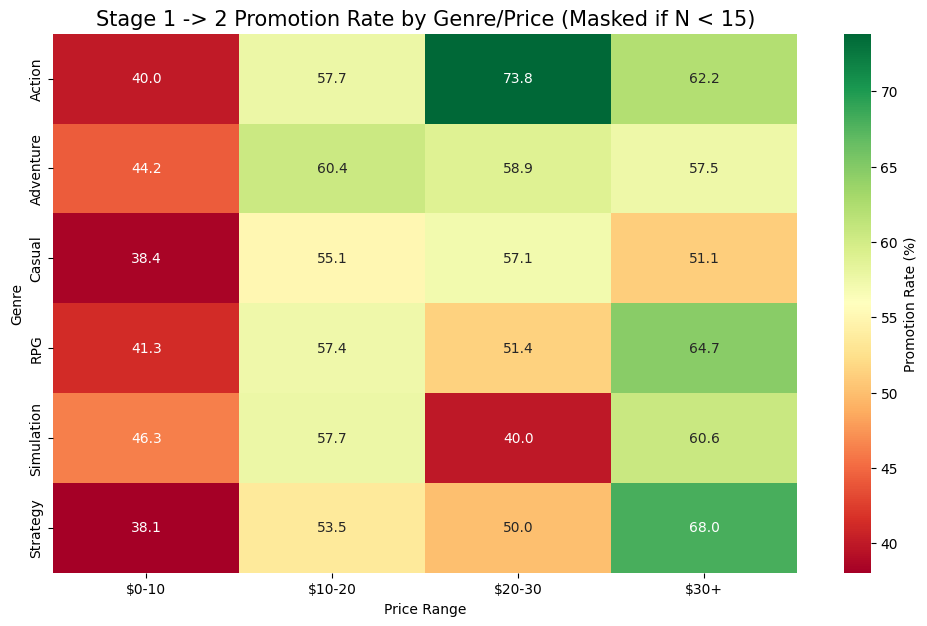


[ 1단계 정체 게임 특성 분석 ]
genres_list price_range  Game_Count
     Action       $0-10        2763
     Action      $10-20         220
     Action      $20-30          11
     Action        $30+          14
  Adventure       $0-10        2550
  Adventure      $10-20         237
  Adventure      $20-30          23
  Adventure        $30+          17
     Casual       $0-10        3246
     Casual      $10-20         186
     Casual      $20-30          21
     Casual        $30+          23
        RPG       $0-10         983
        RPG      $10-20         112
        RPG      $20-30          18
 Simulation       $0-10        1073
 Simulation      $10-20         104
 Simulation      $20-30          21
 Simulation        $30+          13
   Strategy       $0-10        1234
   Strategy      $10-20         128
   Strategy      $20-30          16


In [14]:
base_path = '../../data/preprocessed/'
df_graded = pd.read_csv(os.path.join(base_path, 'steam_indie_games_graded.csv'))
df_silence = pd.read_csv(os.path.join(base_path, 'steam_indie_games_silence.csv'))
hist_df = pd.read_csv(os.path.join(base_path, 'steam_indie_review_histogram.csv'))

df = pd.concat([df_graded, df_silence], ignore_index=True)
df.drop_duplicates(subset=['appid'], inplace=True)

# 4대 시그널 생성
hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_stats = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')
df = pd.merge(df, stability_stats, on='appid', how='left')

df['sentiment'] = df['positive_rate']
df['safe_owners'] = df['owners_lower'].replace(0, 20000) 
df['value_score'] = df['recommendations_total'].fillna(0) / df['safe_owners']
df[['sentiment', 'value_score', 'stability']] = df[['sentiment', 'value_score', 'stability']].fillna(0)

# 단계 분류 (1단계: 1~9개, 2단계: 10~49개)
df = df[df['total_reviews'] > 0].copy()
df['stage'] = df['total_reviews'].apply(lambda x: 1 if 1 <= x <= 9 else (2 if 10 <= x <= 49 else 3))
df_target = df[df['stage'].isin([1, 2])].copy()

# 장르 데이터 전처리 (리스트 형태 찌꺼기 문자 제거)
df_target['genres'] = df_target['genres'].astype(str).str.replace(r"[\[\]\'\"]", "", regex=True)

# 장르 분리 및 주요 6대 장르 필터링
df_target['genres_list'] = df_target['genres'].str.split(',')
df_exploded = df_target.explode('genres_list')
df_exploded['genres_list'] = df_exploded['genres_list'].str.strip()
df_exploded = df_exploded.reset_index(drop=True)

major_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
df_exploded = df_exploded[df_exploded['genres_list'].isin(major_genres)]

# 가격 범위 설정
df_exploded['price'] = pd.to_numeric(df_exploded['price'], errors='coerce').fillna(0)
max_price = df_exploded['price'].max()
if max_price > 1000:
    bins = [-1, 10000, 20000, 30000, float('inf')]
    labels = ['~10,000₩', '10k~20k₩', '20k~30k₩', '30k₩+']
else:
    bins = [-1, 10, 20, 30, float('inf')]
    labels = ['$0-10', '$10-20', '$20-30', '$30+']

df_exploded['price_range'] = pd.cut(df_exploded['price'], bins=bins, labels=labels)

# 1단계 -> 2단계 진입 성공률 시각화
total_counts = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['appid'].count().unstack()
df_exploded['is_promoted'] = (df_exploded['stage'] == 2).astype(int)
success_map = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['is_promoted'].mean().unstack() * 100

valid_success_map = success_map.where(total_counts >= 15)

plt.figure(figsize=(12, 7))
sns.heatmap(valid_success_map, annot=True, fmt=".1f", cmap="RdYlGn", 
            cbar_kws={'label': 'Promotion Rate (%)'}, mask=valid_success_map.isnull())
plt.title('Stage 1 -> 2 Promotion Rate by Genre/Price (Masked if N < 15)', fontsize=15)
plt.xlabel('Price Range')
plt.ylabel('Genre')
plt.show()

# 1단계 게임들의 평균 지표 비교
stuck_traits = df_exploded[df_exploded['stage'] == 1].groupby(['genres_list', 'price_range'], observed=False).agg(
    Game_Count=('appid', 'count')
).reset_index()

print("\n[ 1단계 정체 게임 특성 분석 ]")
print(stuck_traits[stuck_traits['Game_Count'] >= 10].round(3).to_string(index=False))

ppt 37페이지에 나온 가격대 분포로 변경해서 실행

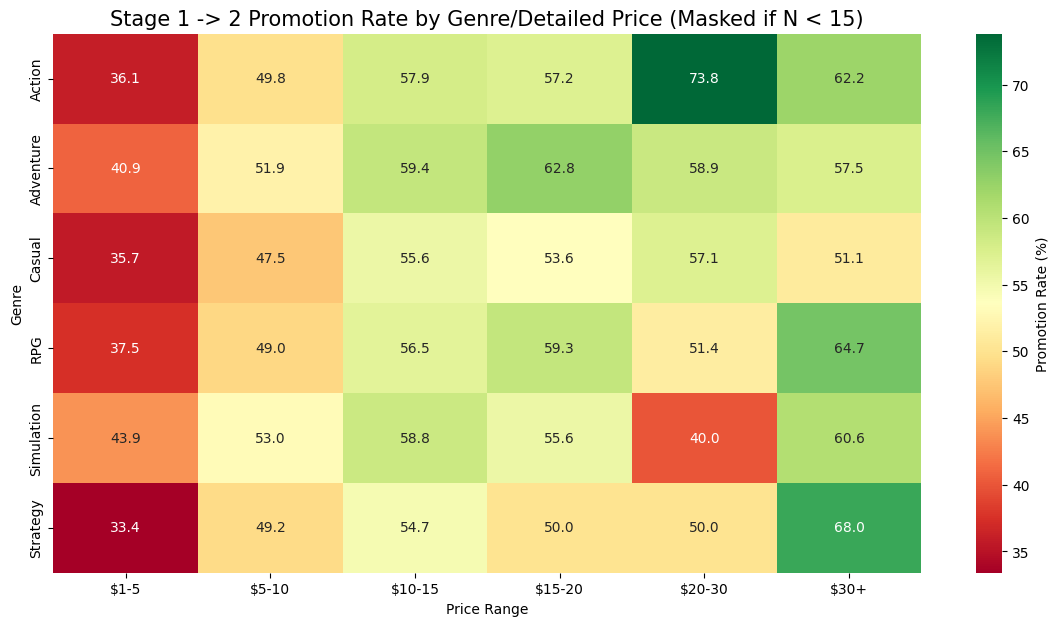


[ 1단계 정체 게임 특성 분석 (세분화된 가격 기준) ]
genres_list price_range  Game_Count
     Action        $1-5        2099
     Action       $5-10         664
     Action      $10-15         155
     Action      $15-20          65
     Action      $20-30          11
     Action        $30+          14
  Adventure        $1-5        1877
  Adventure       $5-10         673
  Adventure      $10-15         167
  Adventure      $15-20          70
  Adventure      $20-30          23
  Adventure        $30+          17
     Casual        $1-5        2612
     Casual       $5-10         634
     Casual      $10-15         134
     Casual      $15-20          52
     Casual      $20-30          21
     Casual        $30+          23
        RPG        $1-5         696
        RPG       $5-10         287
        RPG      $10-15          77
        RPG      $15-20          35
        RPG      $20-30          18
 Simulation        $1-5         829
 Simulation       $5-10         244
 Simulation      $10-15       

In [15]:
# 1. 데이터 로드 및 병합
base_path = '../../data/preprocessed/'
df_graded = pd.read_csv(os.path.join(base_path, 'steam_indie_games_graded.csv'))
df_silence = pd.read_csv(os.path.join(base_path, 'steam_indie_games_silence.csv'))
hist_df = pd.read_csv(os.path.join(base_path, 'steam_indie_review_histogram.csv'))

df = pd.concat([df_graded, df_silence], ignore_index=True)
df.drop_duplicates(subset=['appid'], inplace=True)


# 2. 4대 시그널 생성
hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_stats = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')
df = pd.merge(df, stability_stats, on='appid', how='left')

df['sentiment'] = df['positive_rate']
df['safe_owners'] = df['owners_lower'].replace(0, 20000) 
df['value_score'] = df['recommendations_total'].fillna(0) / df['safe_owners']
df[['sentiment', 'value_score', 'stability']] = df[['sentiment', 'value_score', 'stability']].fillna(0)


# 3. 단계 분류 및 장르 전처리
# 단계 분류 (1단계: 1~9개, 2단계: 10~49개)
df = df[df['total_reviews'] > 0].copy()
df['stage'] = df['total_reviews'].apply(lambda x: 1 if 1 <= x <= 9 else (2 if 10 <= x <= 49 else 3))
df_target = df[df['stage'].isin([1, 2])].copy()

# 장르 데이터 전처리 (리스트 형태 찌꺼기 문자 제거)
df_target['genres'] = df_target['genres'].astype(str).str.replace(r"[\[\]\'\"]", "", regex=True)

# 장르 분리 및 주요 6대 장르 필터링
df_target['genres_list'] = df_target['genres'].str.split(',')
df_exploded = df_target.explode('genres_list')
df_exploded['genres_list'] = df_exploded['genres_list'].str.strip()
df_exploded = df_exploded.reset_index(drop=True)

major_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
df_exploded = df_exploded[df_exploded['genres_list'].isin(major_genres)]

# 4. 세분화된 가격 범위 설정 (5단위 구간)
df_exploded['price'] = pd.to_numeric(df_exploded['price'], errors='coerce').fillna(0)
max_price = df_exploded['price'].max()

if max_price > 1000:
    # 원화(₩) 기준 구간 (0~5천, 5천~1만, 1만~1만5천, 1만5천~2만, 2만~3만, 3만 이상)
    bins = [-1, 5000, 10000, 15000, 20000, 30000, float('inf')]
    labels = ['~5k₩', '5k~10k₩', '10k~15k₩', '15k~20k₩', '20k~30k₩', '30k₩+']
else:
    # 달러($) 기준 구간 (1~5, 5~10, 10~15, 15~20, 20~30, 30 이상)
    bins = [0, 5, 10, 15, 20, 30, float('inf')]
    labels = ['$1-5', '$5-10', '$10-15', '$15-20', '$20-30', '$30+']

df_exploded['price_range'] = pd.cut(df_exploded['price'], bins=bins, labels=labels)


# 5. 1단계 -> 2단계 진입 성공률 시각화 (히트맵)
total_counts = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['appid'].count().unstack()
df_exploded['is_promoted'] = (df_exploded['stage'] == 2).astype(int)
success_map = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['is_promoted'].mean().unstack() * 100

# 노이즈 제거: 표본이 15개 미만인 구간은 마스킹(가림) 처리
valid_success_map = success_map.where(total_counts >= 15)

plt.figure(figsize=(14, 7))
sns.heatmap(valid_success_map, annot=True, fmt=".1f", cmap="RdYlGn", 
            cbar_kws={'label': 'Promotion Rate (%)'}, mask=valid_success_map.isnull())
plt.title('Stage 1 -> 2 Promotion Rate by Genre/Detailed Price (Masked if N < 15)', fontsize=15)
plt.xlabel('Price Range')
plt.ylabel('Genre')
plt.show()


# 6. 1단계 정체 게임들의 평균 지표 비교
stuck_traits = df_exploded[df_exploded['stage'] == 1].groupby(['genres_list', 'price_range'], observed=False).agg(
    Game_Count=('appid', 'count'),
).reset_index()

print("\n[ 1단계 정체 게임 특성 분석 (세분화된 가격 기준) ]")
print(stuck_traits[stuck_traits['Game_Count'] >= 10].round(3).to_string(index=False))

색상만 변경하여 전체의 평균을 기준으로 색상 적용하게, 기존은 50% 기준으로 빨강, 초록이었음


 [ 1단계 -> 2단계 진입 성공률 (%) 텍스트 데이터 ]
* 표본(게임 수)이 15개 미만인 구간은 NaN(결측치)으로 표시됩니다.

price_range  $1-5  $5-10  $10-15  $15-20  $20-30  $30+
genres_list                                           
Action       36.1   49.8    57.9    57.2    73.8  62.2
Adventure    40.9   51.9    59.4    62.8    58.9  57.5
Casual       35.7   47.5    55.6    53.6    57.1  51.1
RPG          37.5   49.0    56.5    59.3    51.4  64.7
Simulation   43.9   53.0    58.8    55.6    40.0  60.6
Strategy     33.4   49.2    54.7    50.0    50.0  68.0



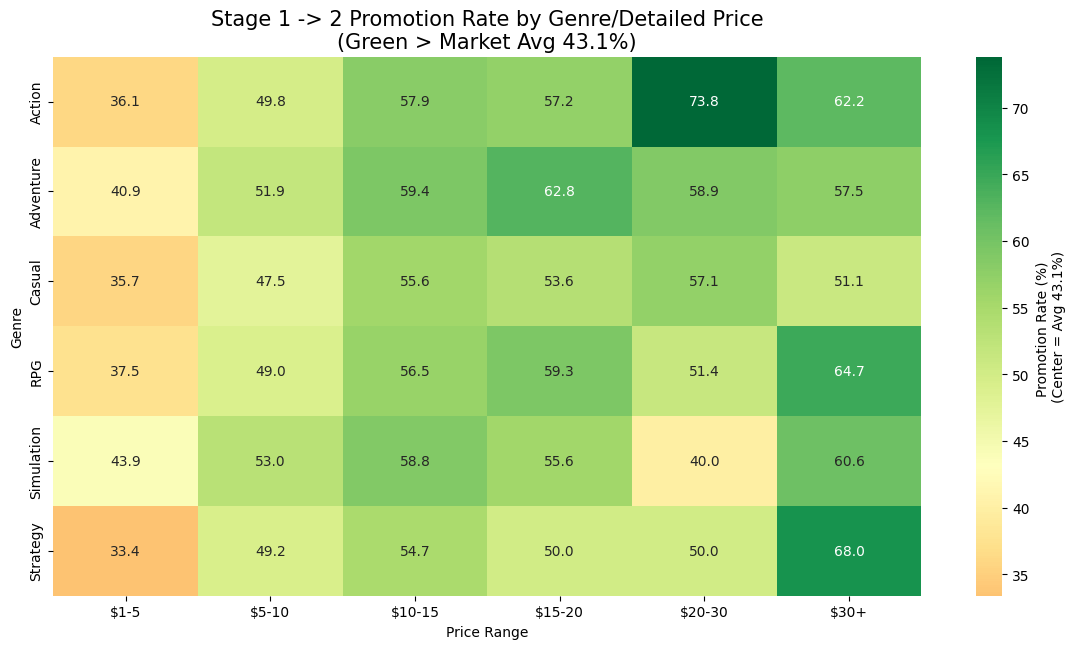


[ 1단계 정체 게임 특성 분석 (세분화된 가격 기준) ]
genres_list price_range  Game_Count
     Action        $1-5        2099
     Action       $5-10         664
     Action      $10-15         155
     Action      $15-20          65
     Action      $20-30          11
     Action        $30+          14
  Adventure        $1-5        1877
  Adventure       $5-10         673
  Adventure      $10-15         167
  Adventure      $15-20          70
  Adventure      $20-30          23
  Adventure        $30+          17
     Casual        $1-5        2612
     Casual       $5-10         634
     Casual      $10-15         134
     Casual      $15-20          52
     Casual      $20-30          21
     Casual        $30+          23
        RPG        $1-5         696
        RPG       $5-10         287
        RPG      $10-15          77
        RPG      $15-20          35
        RPG      $20-30          18
 Simulation        $1-5         829
 Simulation       $5-10         244
 Simulation      $10-15       

In [16]:
# 1. 데이터 로드 및 병합
base_path = '../../data/preprocessed/'
df_graded = pd.read_csv(os.path.join(base_path, 'steam_indie_games_graded.csv'))
df_silence = pd.read_csv(os.path.join(base_path, 'steam_indie_games_silence.csv'))
hist_df = pd.read_csv(os.path.join(base_path, 'steam_indie_review_histogram.csv'))

df = pd.concat([df_graded, df_silence], ignore_index=True)
df.drop_duplicates(subset=['appid'], inplace=True)


# 2. 4대 시그널 생성
hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_stats = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')
df = pd.merge(df, stability_stats, on='appid', how='left')

df['sentiment'] = df['positive_rate']
df['safe_owners'] = df['owners_lower'].replace(0, 20000) 
df['value_score'] = df['recommendations_total'].fillna(0) / df['safe_owners']
df[['sentiment', 'value_score', 'stability']] = df[['sentiment', 'value_score', 'stability']].fillna(0)


# 3. 단계 분류 및 장르 전처리
# 단계 분류 (1단계: 1~9개, 2단계: 10~49개)
df = df[df['total_reviews'] > 0].copy()
df['stage'] = df['total_reviews'].apply(lambda x: 1 if 1 <= x <= 9 else (2 if 10 <= x <= 49 else 3))
df_target = df[df['stage'].isin([1, 2])].copy()

# 장르 데이터 전처리 (리스트 형태 찌꺼기 문자 제거)
df_target['genres'] = df_target['genres'].astype(str).str.replace(r"[\[\]\'\"]", "", regex=True)

# 장르 분리 및 주요 6대 장르 필터링
df_target['genres_list'] = df_target['genres'].str.split(',')
df_exploded = df_target.explode('genres_list')
df_exploded['genres_list'] = df_exploded['genres_list'].str.strip()
df_exploded = df_exploded.reset_index(drop=True)

major_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
df_exploded = df_exploded[df_exploded['genres_list'].isin(major_genres)]


# 4. 세분화된 가격 범위 설정 (5단위 구간)
df_exploded['price'] = pd.to_numeric(df_exploded['price'], errors='coerce').fillna(0)

# 결측치 방지
df_exploded = df_exploded[df_exploded['price'] > 0].copy()

max_price = df_exploded['price'].max()

if max_price > 1000:
    # 원화(₩) 기준 구간 (0~5천, 5천~1만, 1만~1만5천, 1만5천~2만, 2만~3만, 3만 이상)
    bins = [0, 5000, 10000, 15000, 20000, 30000, float('inf')]
    labels = ['~5k₩', '5k~10k₩', '10k~15k₩', '15k~20k₩', '20k~30k₩', '30k₩+']
else:
    # 달러($) 기준 구간 (1~5, 5~10, 10~15, 15~20, 20~30, 30 이상)
    bins = [0, 5, 10, 15, 20, 30, float('inf')]
    labels = ['$1-5', '$5-10', '$10-15', '$15-20', '$20-30', '$30+']

df_exploded['price_range'] = pd.cut(df_exploded['price'], bins=bins, labels=labels)


# 5. 2단계 진입 성공률 시각화 및 텍스트 출력
total_counts = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['appid'].count().unstack()
df_exploded['is_promoted'] = (df_exploded['stage'] == 2).astype(int)
success_map = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['is_promoted'].mean().unstack() * 100

# 표본이 15개 미만인 구간은 마스킹(가림) 처리
valid_success_map = success_map.where(total_counts >= 15)

# 히트맵 결과를 텍스트(표) 형태로 먼저 출력
print("\n===========================================================")
print(" [ 1단계 -> 2단계 진입 성공률 (%) 텍스트 데이터 ]")
print("===========================================================")
print("* 표본(게임 수)이 15개 미만인 구간은 NaN(결측치)으로 표시됩니다.\n")
print(valid_success_map.round(1).to_string())
print("===========================================================\n")

# 히트맵 그리기
# (기저율 계산 추가 - 50% 기준이 아닌 시장 평균 기준으로 색상 출력)
baseline_rate = df_exploded['is_promoted'].mean() * 100

plt.figure(figsize=(14, 7))
sns.heatmap(valid_success_map, annot=True, fmt=".1f", cmap="RdYlGn", center=baseline_rate,
            cbar_kws={'label': f'Promotion Rate (%) \n(Center = Avg {baseline_rate:.1f}%)'}, 
            mask=valid_success_map.isnull())
plt.title(f'Stage 1 -> 2 Promotion Rate by Genre/Detailed Price\n(Green > Market Avg {baseline_rate:.1f}%)', fontsize=15)
plt.xlabel('Price Range')
plt.ylabel('Genre')
plt.show()


# 6. 1단계 정체 게임들의 평균 지표 비교
stuck_traits = df_exploded[df_exploded['stage'] == 1].groupby(['genres_list', 'price_range'], observed=False).agg(
    Game_Count=('appid', 'count'),
).reset_index()

print("\n[ 1단계 정체 게임 특성 분석 (세분화된 가격 기준) ]")
print(stuck_traits[stuck_traits['Game_Count'] >= 10].round(3).to_string(index=False))

파랑이 좋겠군


 [ 1단계 -> 2단계 진입 성공률 (%) 텍스트 데이터 ]
* 표본(게임 수)이 15개 미만인 구간은 NaN(결측치)으로 표시됩니다.

price_range  $1-5  $5-10  $10-15  $15-20  $20-30  $30+
genres_list                                           
Action       36.1   49.8    57.9    57.2    73.8  62.2
Adventure    40.9   51.9    59.4    62.8    58.9  57.5
Casual       35.7   47.5    55.6    53.6    57.1  51.1
RPG          37.5   49.0    56.5    59.3    51.4  64.7
Simulation   43.9   53.0    58.8    55.6    40.0  60.6
Strategy     33.4   49.2    54.7    50.0    50.0  68.0



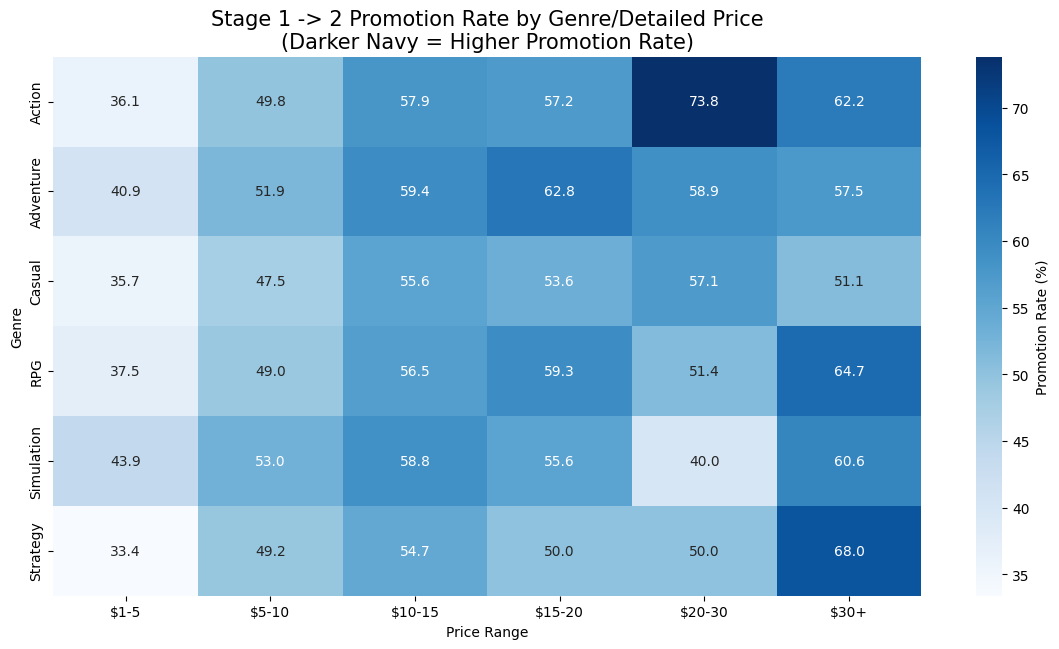


[ 1단계 정체 게임 특성 분석 (세분화된 가격 기준) ]
genres_list price_range  Game_Count
     Action        $1-5        2099
     Action       $5-10         664
     Action      $10-15         155
     Action      $15-20          65
     Action      $20-30          11
     Action        $30+          14
  Adventure        $1-5        1877
  Adventure       $5-10         673
  Adventure      $10-15         167
  Adventure      $15-20          70
  Adventure      $20-30          23
  Adventure        $30+          17
     Casual        $1-5        2612
     Casual       $5-10         634
     Casual      $10-15         134
     Casual      $15-20          52
     Casual      $20-30          21
     Casual        $30+          23
        RPG        $1-5         696
        RPG       $5-10         287
        RPG      $10-15          77
        RPG      $15-20          35
        RPG      $20-30          18
 Simulation        $1-5         829
 Simulation       $5-10         244
 Simulation      $10-15       

In [17]:
# 1. 데이터 로드 및 병합
base_path = '../../data/preprocessed/'
df_graded = pd.read_csv(os.path.join(base_path, 'steam_indie_games_graded.csv'))
df_silence = pd.read_csv(os.path.join(base_path, 'steam_indie_games_silence.csv'))
hist_df = pd.read_csv(os.path.join(base_path, 'steam_indie_review_histogram.csv'))

df = pd.concat([df_graded, df_silence], ignore_index=True)
df.drop_duplicates(subset=['appid'], inplace=True)

# 2. 4대 시그널 생성
hist_df['daily_pos_rate'] = (hist_df['recommendations_up'] / (hist_df['recommendations_up'] + hist_df['recommendations_down'] + 1e-6)) * 100
stability_stats = hist_df.groupby('appid')['daily_pos_rate'].std().reset_index(name='stability')
df = pd.merge(df, stability_stats, on='appid', how='left')

df['sentiment'] = df['positive_rate']
df['safe_owners'] = df['owners_lower'].replace(0, 20000) 
df['value_score'] = df['recommendations_total'].fillna(0) / df['safe_owners']
df[['sentiment', 'value_score', 'stability']] = df[['sentiment', 'value_score', 'stability']].fillna(0)


# 3. 단계 분류 및 장르 전처리
# 단계 분류 (1단계: 1~9개, 2단계: 10~49개)
df = df[df['total_reviews'] > 0].copy()
df['stage'] = df['total_reviews'].apply(lambda x: 1 if 1 <= x <= 9 else (2 if 10 <= x <= 49 else 3))
df_target = df[df['stage'].isin([1, 2])].copy()

# 장르 데이터 전처리
df_target['genres'] = df_target['genres'].astype(str).str.replace(r"[\[\]\'\"]", "", regex=True)

# 장르 분리 및 주요 6대 장르 필터링
df_target['genres_list'] = df_target['genres'].str.split(',')
df_exploded = df_target.explode('genres_list')
df_exploded['genres_list'] = df_exploded['genres_list'].str.strip()
df_exploded = df_exploded.reset_index(drop=True)

major_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
df_exploded = df_exploded[df_exploded['genres_list'].isin(major_genres)]


# 4. 세분화된 가격 범위 설정 (5단위 구간)
df_exploded['price'] = pd.to_numeric(df_exploded['price'], errors='coerce').fillna(0)

# 0달러 데이터 완벽 제거 로직 추가
df_exploded = df_exploded[df_exploded['price'] > 0].copy()

max_price = df_exploded['price'].max()

if max_price > 1000:
    bins = [0, 5000, 10000, 15000, 20000, 30000, float('inf')]
    labels = ['~5k₩', '5k~10k₩', '10k~15k₩', '15k~20k₩', '20k~30k₩', '30k₩+']
else:
    bins = [0, 5, 10, 15, 20, 30, float('inf')]
    labels = ['$1-5', '$5-10', '$10-15', '$15-20', '$20-30', '$30+']

df_exploded['price_range'] = pd.cut(df_exploded['price'], bins=bins, labels=labels)

# 5. 1단계 -> 2단계 진입 성공률 시각화 (남색 계열로 수정)
total_counts = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['appid'].count().unstack()
df_exploded['is_promoted'] = (df_exploded['stage'] == 2).astype(int)
success_map = df_exploded.groupby(['genres_list', 'price_range'], observed=False)['is_promoted'].mean().unstack() * 100

# 표본이 15개 미만인 구간은 마스킹(가림) 처리
valid_success_map = success_map.where(total_counts >= 15)

# 히트맵 결과를 텍스트(표) 형태로 먼저 출력
print("\n===========================================================")
print(" [ 1단계 -> 2단계 진입 성공률 (%) 텍스트 데이터 ]")
print("===========================================================")
print("* 표본(게임 수)이 15개 미만인 구간은 NaN(결측치)으로 표시됩니다.\n")
print(valid_success_map.round(1).to_string())
print("===========================================================\n")

# 히트맵 그리기
plt.figure(figsize=(14, 7))
sns.heatmap(valid_success_map, annot=True, fmt=".1f", cmap="Blues",
            cbar_kws={'label': 'Promotion Rate (%)'}, 
            mask=valid_success_map.isnull())

# 제목과 라벨 수정 (남색의 의미 강조)
plt.title('Stage 1 -> 2 Promotion Rate by Genre/Detailed Price\n(Darker Navy = Higher Promotion Rate)', fontsize=15)
plt.xlabel('Price Range')
plt.ylabel('Genre')
plt.show()


# 6. 1단계 정체 게임들의 평균 지표 비교
stuck_traits = df_exploded[df_exploded['stage'] == 1].groupby(['genres_list', 'price_range'], observed=False).agg(
    Game_Count=('appid', 'count'),
).reset_index()

print("\n[ 1단계 정체 게임 특성 분석 (세분화된 가격 기준) ]")
print(stuck_traits[stuck_traits['Game_Count'] >= 10].round(3).to_string(index=False))

가격대별 평균 흥행 점수 부여

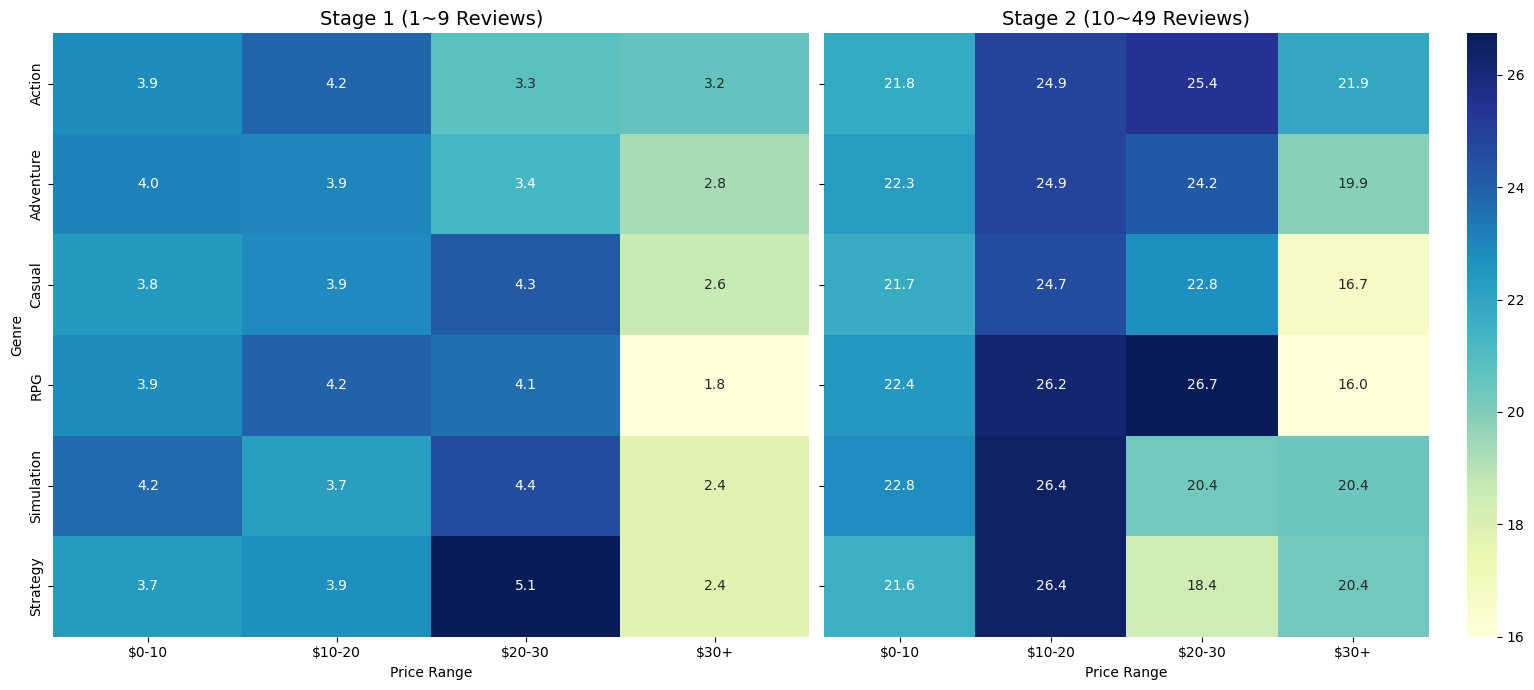


[ 1단계 vs 2단계 장르/가격대별 요약 ]
 stage genres_list price_range  평균_흥행  게임_수
     1      Action       $0-10    3.9  2763
     1      Action      $10-20    4.2   220
     1      Action      $20-30    3.3    11
     1      Action        $30+    3.2    14
     1   Adventure       $0-10    4.0  2550
     1   Adventure      $10-20    3.9   237
     1   Adventure      $20-30    3.4    23
     1   Adventure        $30+    2.8    17
     1      Casual       $0-10    3.8  3246
     1      Casual      $10-20    3.9   186
     1      Casual      $20-30    4.3    21
     1      Casual        $30+    2.6    23
     1         RPG       $0-10    3.9   983
     1         RPG      $10-20    4.2   112
     1         RPG      $20-30    4.1    18
     1         RPG        $30+    1.8     6
     1  Simulation       $0-10    4.2  1073
     1  Simulation      $10-20    3.7   104
     1  Simulation      $20-30    4.4    21
     1  Simulation        $30+    2.4    13
     1    Strategy       $0-10    3.7  1234
     

In [18]:
# 1. 데이터 로드 및 병합
base_path = '../../data/preprocessed/'
df_graded = pd.read_csv(os.path.join(base_path, 'steam_indie_games_graded.csv'))
df_silence = pd.read_csv(os.path.join(base_path, 'steam_indie_games_silence.csv'))

df = pd.concat([df_graded, df_silence], ignore_index=True)
df.drop_duplicates(subset=['appid'], inplace=True)

# 2. 단계 분류 (0단계 제외, 1단계/2단계만 타겟)
df = df[df['total_reviews'] > 0].copy()
df['stage'] = df['total_reviews'].apply(lambda x: 1 if 1 <= x <= 9 else (2 if 10 <= x <= 49 else 3))
df_target = df[df['stage'].isin([1, 2])].copy()

# 3. 장르 데이터 클렌징 및 분리 (데이터 증발 방지)
df_target['genres'] = df_target['genres'].astype(str).str.replace(r"[\[\]\'\"]", "", regex=True)
df_target['genres_list'] = df_target['genres'].fillna('Unknown').str.split(',')
df_exploded = df_target.explode('genres_list')
df_exploded['genres_list'] = df_exploded['genres_list'].str.strip()
df_exploded = df_exploded.reset_index(drop=True)

major_genres = ['Action', 'Adventure', 'Casual', 'RPG', 'Simulation', 'Strategy']
df_exploded = df_exploded[df_exploded['genres_list'].isin(major_genres)]

# 4. 가격 범위 설정 (원화/달러 자동 대응)
df_exploded['price'] = pd.to_numeric(df_exploded['price'], errors='coerce').fillna(0)
if df_exploded['price'].max() > 1000:
    bins = [-1, 10000, 20000, 30000, float('inf')]
    labels = ['~10,000₩', '10k~20k₩', '20k~30k₩', '30k₩+']
else:
    bins = [-1, 10, 20, 30, float('inf')]
    labels = ['$0-10', '$10-20', '$20-30', '$30+']

df_exploded['price_range'] = pd.cut(df_exploded['price'], bins=bins, labels=labels)

# 5. 단계별 지표 집계
stats = df_exploded.groupby(['stage', 'genres_list', 'price_range'], observed=False).agg(
    평균_흥행=('total_reviews', 'mean'),
    게임_수=('appid', 'count')
).reset_index()

# 6. 시각화 (Stage 1 vs Stage 2)
stages = [1, 2]
stage_names = {1: 'Stage 1 (1~9 Reviews)', 2: 'Stage 2 (10~49 Reviews)'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for i, stage in enumerate(stages):
    subset = stats[stats['stage'] == stage]
    pivoted = subset.pivot(index='genres_list', columns='price_range', values='평균_흥행')
    sns.heatmap(pivoted, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i], cbar=(i == 1))
    axes[i].set_title(stage_names[stage], fontsize=14)
    axes[i].set_xlabel("Price Range")
    if i == 0:
        axes[i].set_ylabel("Genre")
    else:
        axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

print("\n[ 1단계 vs 2단계 장르/가격대별 요약 ]")
print(stats[stats['게임_수'] > 0].round(1).to_string(index=False))